                                   Top 5 rows                                   
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1         1/1/2023          7:06:11                2   
1               2         1/1/2023          7:08:56                2   
2               3         1/1/2023          7:14:04                2   
3               4         1/1/2023          7:20:24                1   
4               5         1/1/2023          7:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type     

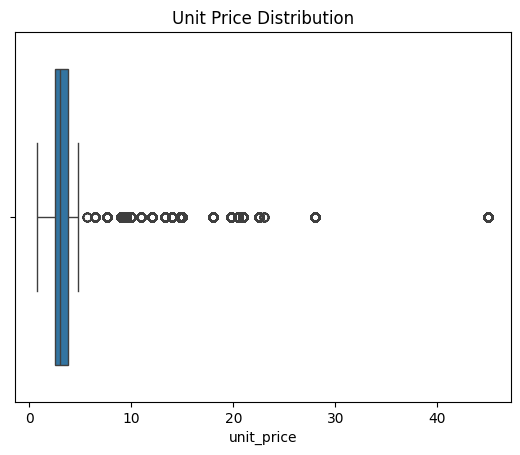

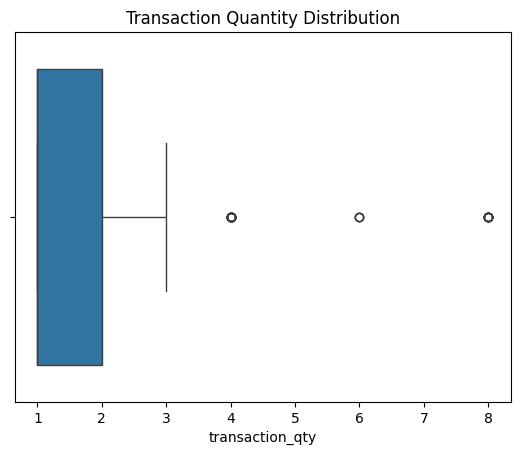

In [1]:
                                                  #Dataset Understanding & Setup
import pandas as pd
df=pd.read_csv("Coffee Shop Sales.csv")
print("Top 5 rows".center(80))
print(df.head())
print("Shape of dataset".center(80))
print(df.shape)
print("Columns in dataset".center(80))
print(df.columns)
print("Information about dataset".center(80))
print(df.info())
# print("Calculations of number columns".center(80))
# print(df.describe)
print("Now Check for missing values".center(80))
print(df.isnull().sum())
print("Duplicate rows".center(80))
print(df.duplicated().sum())
                                                   #Data Cleaning

# Convert transaction_date and transaction_time columns to correct datatype
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%m/%d/%Y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

# Standardize Column Names
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')

# Adding a Total Price Column
df['total_price']=df['transaction_qty']*df['unit_price']

# Checking for Outliers in Price & Quantity
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['unit_price'])
plt.title("Unit Price Distribution")
plt.show()

sns.boxplot(x=df['transaction_qty'])
plt.title("Transaction Quantity Distribution")
plt.show()

# Save the Cleaned Dataset
df.to_csv("Coffee shop sales_cleaned.csv", index=False)


In [2]:
                                                       # basic checks
print(df.shape) #Columns convert from 11 to 12
print(df.dtypes)
print(df[['transaction_date','transaction_qty','unit_price','total_price']].head())#Checking our new column total_price working
print(df['transaction_date'].min(),df['transaction_date'].max())

                                                #Summary of products
print("Summary of products".center(80))
product_summary = df.groupby('product_detail').agg({
    'transaction_qty': 'sum',
    'total_price': 'sum'
}).reset_index()
print(product_summary.head())

print('Compute Total Sales (Revenue)'.center(80))
                                      # Calculate total sales per transaction

df['total_price'] = df['unit_price'] * df['transaction_qty']

# Group by product_category to get total revenue per category
category_sales = df.groupby('product_category')['total_price'].sum().reset_index()

# Sort categories by revenue (highest first)
category_sales = category_sales.sort_values(by='total_price', ascending=False)

print(category_sales)
# Top 10 & Bottom 10 Products by Revenue
print('Top 10 & Bottom 10 Products by Revenue'.center(80))
# Sort by revenue
product_summary_sorted = product_summary.sort_values(by='total_price', ascending=False)

# Top 10 products
top10_products = product_summary_sorted.head(10)
print("\nTop 10 Products by Revenue:\n", top10_products)

# Bottom 10 products
bottom10_products = product_summary_sorted.tail(10)
print("\nBottom 10 Products by Revenue:\n", bottom10_products)


(149116, 12)
transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
total_price                float64
dtype: object
  transaction_date  transaction_qty  unit_price  total_price
0       2023-01-01                2         3.0          6.0
1       2023-01-01                2         3.1          6.2
2       2023-01-01                2         4.5          9.0
3       2023-01-01                1         2.0          2.0
4       2023-01-01                2         3.1          6.2
2023-01-01 00:00:00 2023-06-30 00:00:00
                              Summary of products                               
        product_detail  transaction_qty  total_price
0     Almond 

                Visualization – Total Sales by Product (Top 10)                 


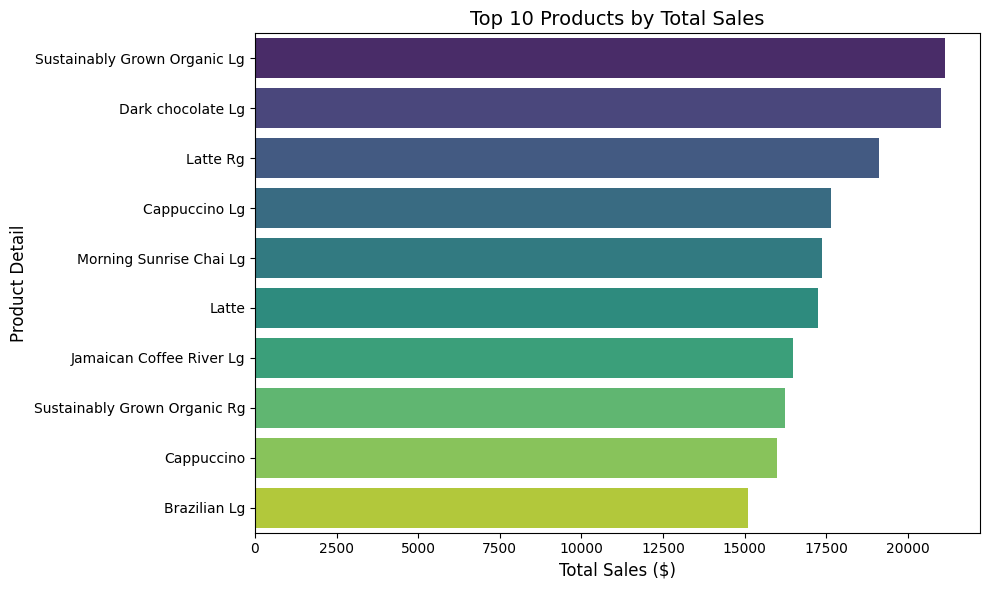

                Step 1: Assuming Cost Price as 70% of Unit Price                
                   Step 2: Calculating Profit per Transaction                   
                    Step 3: Creating Product Profit Summary                     
                   Step 4: Sorting Products by Highest Profit                   
                  product_detail  transaction_qty  total_price    profit
75  Sustainably Grown Organic Lg             4453     21151.75  6345.525
20             Dark chocolate Lg             4668     21006.00  6301.800
48                      Latte Rg             4497     19112.25  5733.675
6                  Cappuccino Lg             4151     17641.75  5292.525
53       Morning Sunrise Chai Lg             4346     17384.00  5215.200
47                         Latte             4602     17257.50  5177.250
43      Jamaican Coffee River Lg             4395     16481.25  4944.375
76  Sustainably Grown Organic Rg             4329     16233.75  4870.125
5                  

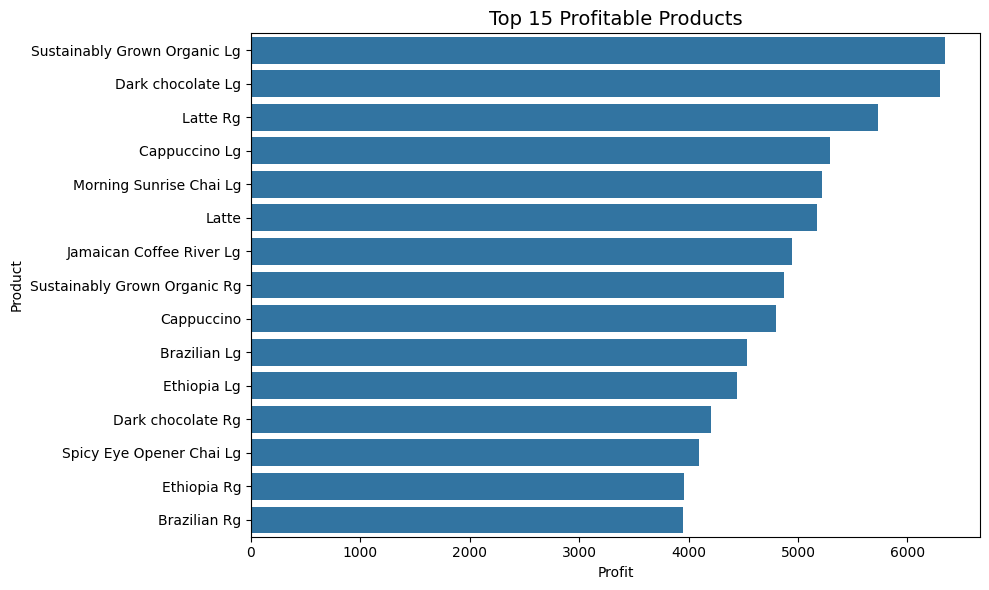

                Step 6: Visualizing Top 15 Loss-Making Products                 


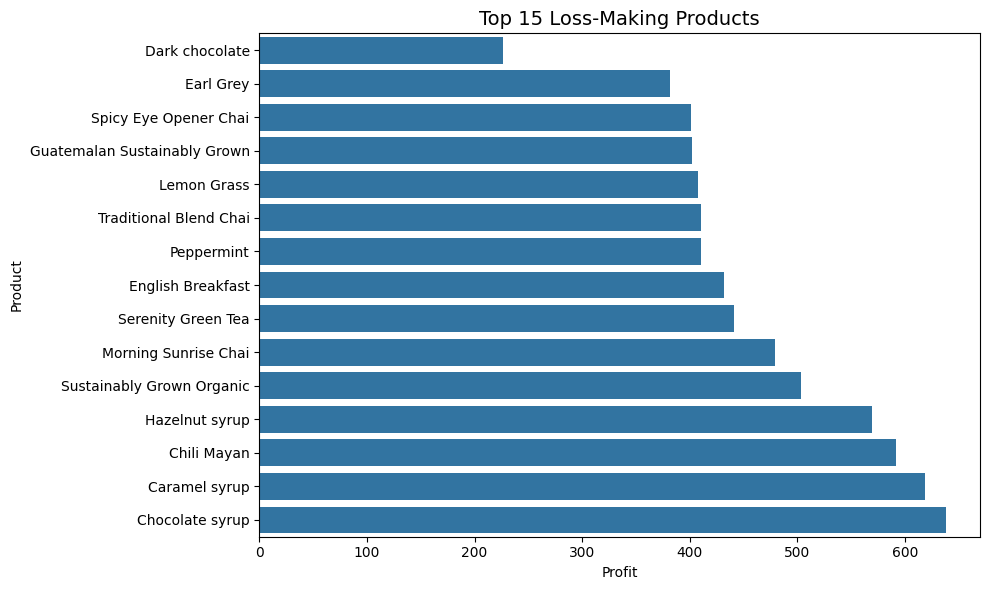

In [3]:
                                          # Visualization – Total Sales by Product (Top 10)
print('Visualization – Total Sales by Product (Top 10)'.center(80))
# Get Top 10 products by total sales
product_summary_sorted = product_summary.sort_values(by='total_price', ascending=False)
top10_products = product_summary_sorted.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_products, 
    x='total_price', 
    y='product_detail', 
    hue='product_detail',   # avoid color issues
    palette='viridis', 
    dodge=False, 
    legend=False            # avoid duplicate legend
)
plt.title('Top 10 Products by Total Sales', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Detail', fontsize=12)
plt.tight_layout()
plt.show()

print('Step 1: Assuming Cost Price as 70% of Unit Price'.center(80))
                        # Creating a new column 'cost_price' based on 70% of selling price
df['cost_price'] = df['unit_price'] * 0.70

print('Step 2: Calculating Profit per Transaction'.center(80))
df['profit'] = (df['unit_price'] - df['cost_price']) * df['transaction_qty']

print('Step 3: Creating Product Profit Summary'.center(80))
                   # Grouping by product to calculate total quantity sold, total sales, and total profit
profit_summary = df.groupby('product_detail').agg({
    'transaction_qty': 'sum',
    'total_price': 'sum',
    'profit': 'sum'
}).reset_index()

print('Step 4: Sorting Products by Highest Profit'.center(80))
                             # Sorting products from highest to lowest profit
profit_summary = profit_summary.sort_values(by='profit', ascending=False)

# Display top 10 most profitable products
print(profit_summary.head(10))

print('Step 5: Visualizing Top 15 Profitable Products'.center(80))
# Top 15 profitable products
top15_profitable = profit_summary.sort_values(by='profit', ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top15_profitable, x='profit', y='product_detail')
plt.title('Top 15 Profitable Products', fontsize=14)
plt.xlabel('Profit')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

print('Step 6: Visualizing Top 15 Loss-Making Products'.center(80))
# Top 15 loss-making products
top15_loss = profit_summary.sort_values(by='profit', ascending=True).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top15_loss, x='profit', y='product_detail')
plt.title('Top 15 Loss-Making Products', fontsize=14)
plt.xlabel('Profit')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


               Safety Checks & Recompute Key Columns (if needed)                
Dataset ready and saved as Coffee_shop_sales_cleaned_with_profit.csv
            Predictive Modeling — Predicting Profit per Transaction             
MAE : 0.14
RMSE: 0.23
R^2 : 0.93
                        Understanding Feature Importance                        
                                feature  coefficient  abs_coef
4              product_category_Branded    -1.840181  1.840181
6         product_category_Coffee beans    -1.816983  1.816983
0                       transaction_qty     1.083775  1.083775
9            product_category_Loose Tea    -0.793836  0.793836
10  product_category_Packaged Chocolate    -0.784561  0.784561
1                            unit_price     0.439232  0.439232
8             product_category_Flavours    -0.081405  0.081405
11                 product_category_Tea    -0.024583  0.024583
3        store_location_Lower Manhattan    -0.023123  0.023123
5               product_c

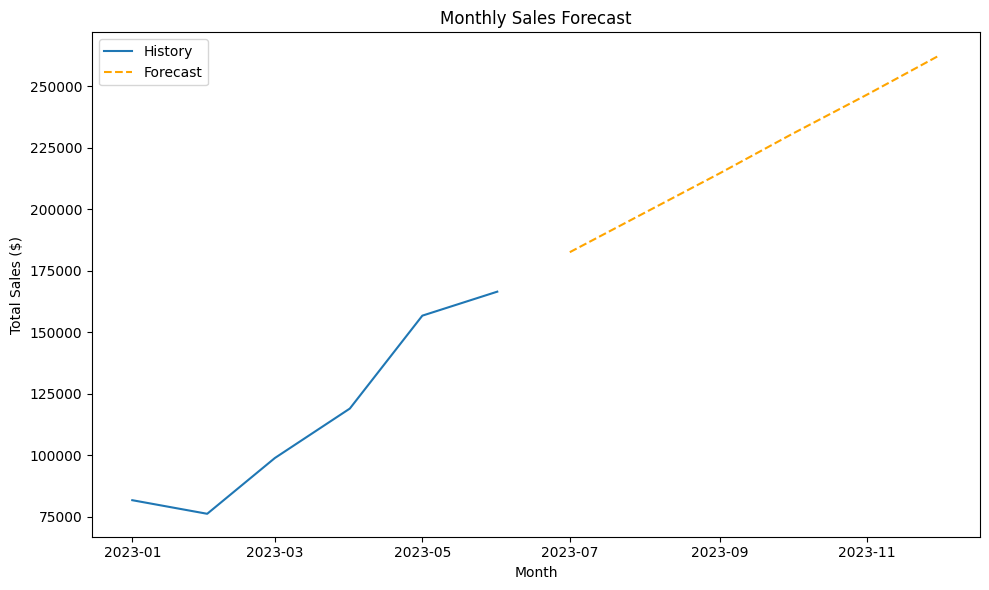

2023-07-01    182539.177394
2023-08-01    198580.607584
2023-09-01    214610.179344
2023-10-01    230627.901439
2023-11-01    246633.782630
2023-12-01    262627.831669
Freq: MS, Name: predicted_mean, dtype: float64
                             Profitability Insights                             
     product_category  total_revenue  total_profit  profit_margin_%
2              Coffee      269952.45     80985.735             30.0
8                 Tea      196405.95     58921.785             30.0
0              Bakery       82315.64     24694.692             30.0
4  Drinking Chocolate       72416.00     21724.800             30.0
3        Coffee beans       40085.25     12025.575             30.0
1             Branded       13607.00      4082.100             30.0
6           Loose Tea       11213.60      3364.080             30.0
5            Flavours        8408.80      2522.640             30.0
7  Packaged Chocolate        4407.64      1322.292             30.0

Top 10 Profitable Produ

In [4]:
print('Safety Checks & Recompute Key Columns (if needed)'.center(80))
import numpy as np

# Ensure transaction_date is in datetime format
if not np.issubdtype(df['transaction_date'].dtype, np.datetime64):
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Add total_price column if missing
if 'total_price' not in df.columns:
    df['total_price'] = df['unit_price'] * df['transaction_qty']

# Add profit column if missing
if 'profit' not in df.columns:
    df['cost_price'] = df['unit_price'] * 0.70
    df['profit'] = (df['unit_price'] - df['cost_price']) * df['transaction_qty']

# Save cleaned dataset
df.to_csv("Coffee_shop_sales_cleaned_with_profit.csv", index=False)
print("Dataset ready and saved as Coffee_shop_sales_cleaned_with_profit.csv")

                               #Predictive Modeling
print('Predictive Modeling — Predicting Profit per Transaction'.center(80))
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Select features and target
num_features = ['transaction_qty', 'unit_price']
cat_features = ['store_location', 'product_category']
target = 'profit'

# Prepare dataset
model_df = df[num_features + cat_features + [target]].dropna()
X = model_df[num_features + cat_features]
y = model_df[target]

# Preprocessing
preprocess = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])

# Pipeline
reg_pipe = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_pipe.fit(X_train, y_train)

# Evaluation
y_pred = reg_pipe.predict(X_test)
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")
print(f"R^2 : {r2_score(y_test, y_pred):.2f}")

                                  #Understanding Feature Importance
print('Understanding Feature Importance'.center(80))
# Get feature names after encoding
oh = reg_pipe.named_steps['prep'].named_transformers_['cat']
oh_features = list(oh.get_feature_names_out(cat_features))
all_features = num_features + oh_features

# Get coefficients and sort by importance
coefs = reg_pipe.named_steps['model'].coef_.ravel()
coef_df = pd.DataFrame({'feature': all_features, 'coefficient': coefs, 'abs_coef': np.abs(coefs)})
coef_df = coef_df.sort_values('abs_coef', ascending=False)
print(coef_df.head(10))

                                  #Monthly Sales Forecast (ARIMA)
print('Monthly Sales Forecast (ARIMA)'.center(80))
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Prepare monthly sales data
monthly_sales = (
    df.set_index('transaction_date')
      .sort_index()
      .groupby(pd.Grouper(freq='MS'))['total_price']
      .sum()
)

                                      # Build ARIMA model
model = ARIMA(monthly_sales, order=(1,1,1))
model_fit = model.fit()

# Forecast next 6 months
forecast = model_fit.forecast(steps=6)

# Plot forecast vs history
plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales, label='History')
plt.plot(forecast.index, forecast, label='Forecast', linestyle='--', color='orange')
plt.legend()
plt.title("Monthly Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

print(forecast)

#Profitability Insights
print('Profitability Insights'.center(80))
# Category-level profitability
category_profit = df.groupby('product_category').agg(
    total_revenue=('total_price', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()
category_profit['profit_margin_%'] = (category_profit['total_profit'] / category_profit['total_revenue']) * 100
print(category_profit.sort_values('total_profit', ascending=False))

# Top 10 profitable products
top_products = df.groupby('product_detail')['profit'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Profitable Products:\n", top_products)

# Bottom 10 loss-making products
bottom_products = df.groupby('product_detail')['profit'].sum().sort_values().head(10)
print("\nBottom 10 Loss-Making Products:\n", bottom_products)


print('Recommendations & Strategies'.center(80))
print("1) Focus on top revenue products for marketing and bundling.")
print("2) Review bottom profit products — adjust price, portion size, or promote differently.")
print("3) Leverage top-performing categories in promotions.")
print("4) Apply lessons from top store locations to weaker ones.")
print("5) Use sales forecast to prepare inventory and staffing ahead of high-demand months.")
